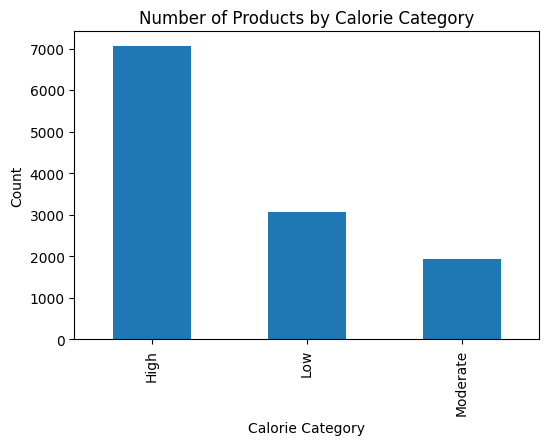

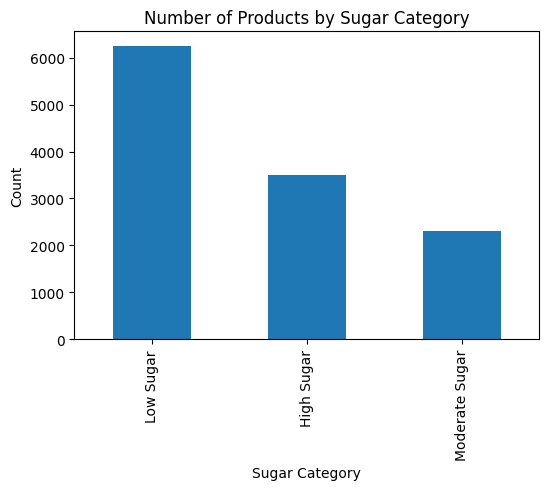

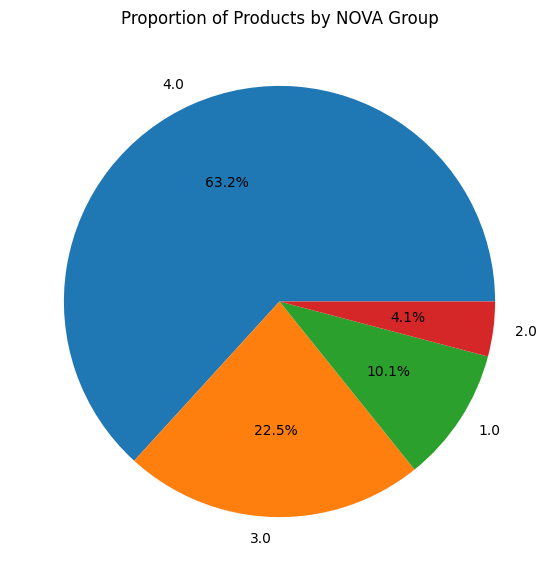

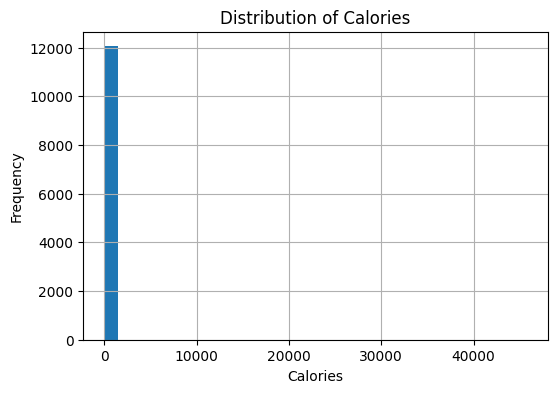

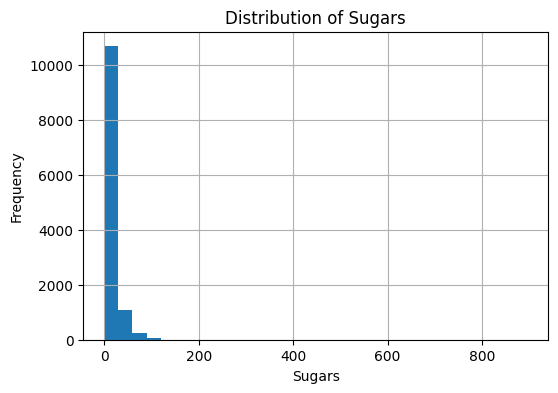

<Figure size 600x400 with 0 Axes>

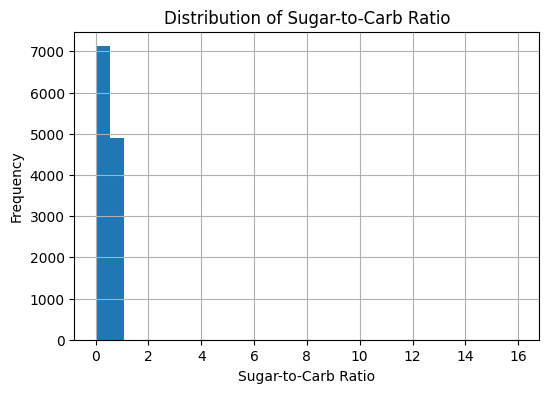

<Figure size 1000x600 with 0 Axes>

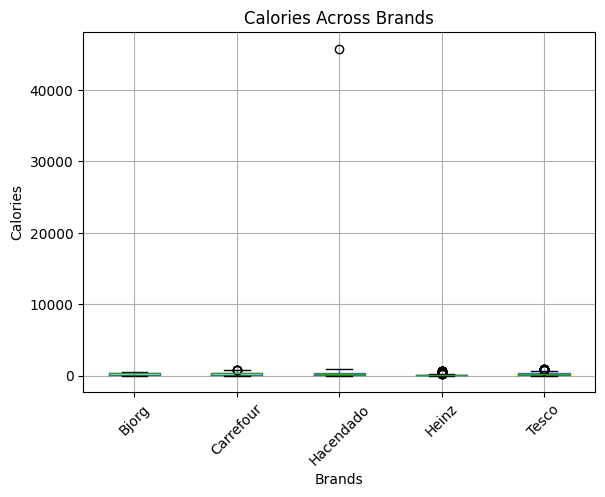

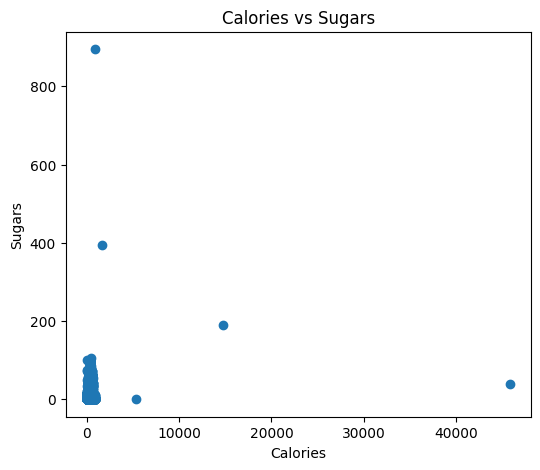

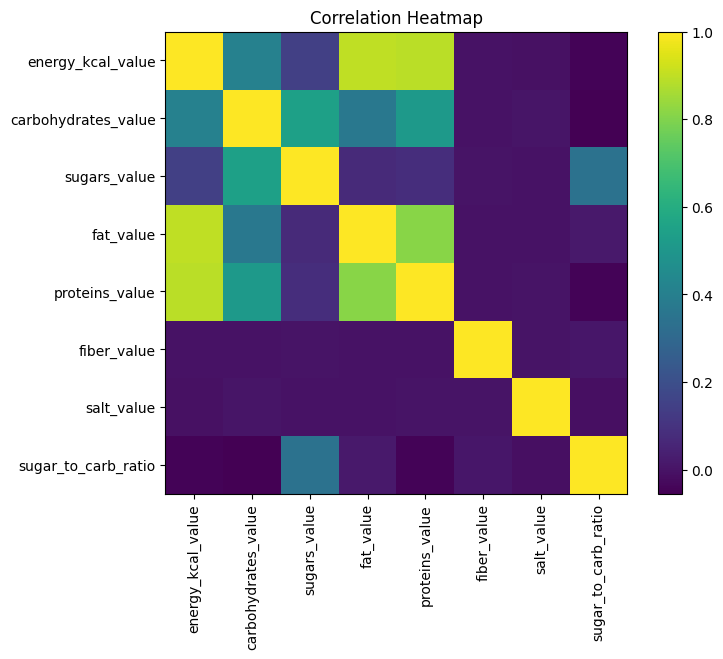

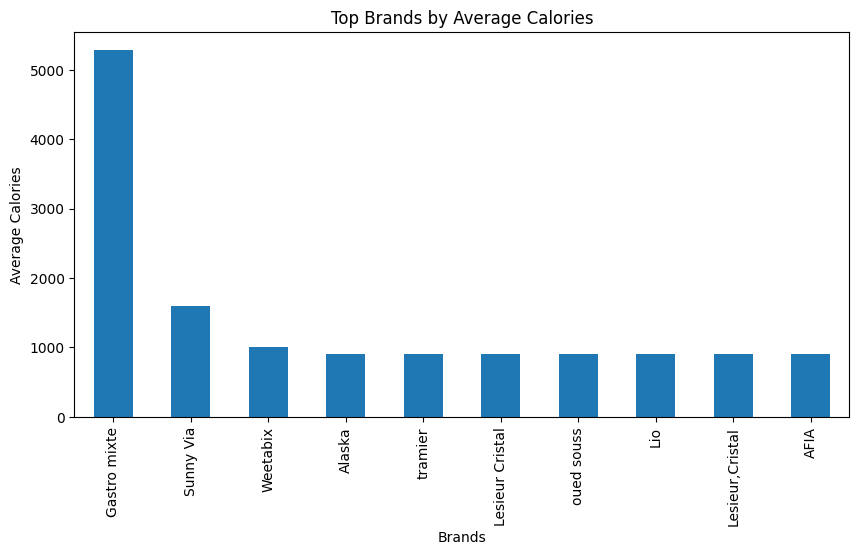

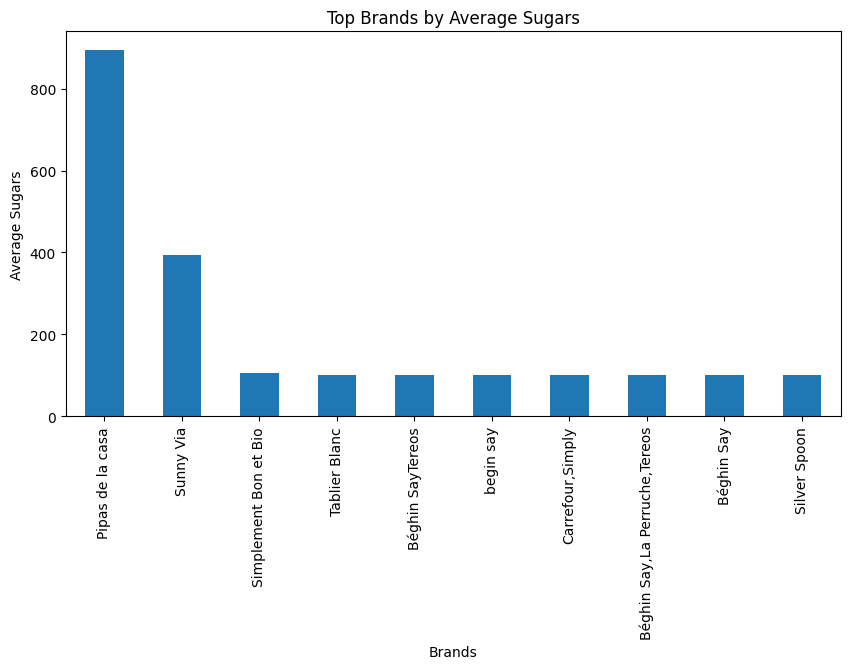

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv("chococrunch_final.csv")

# -----------------------------------
# 1. Bar Charts
# -----------------------------------

# Calorie Category
plt.figure(figsize=(6,4))
df['calorie_category'].value_counts().plot(kind='bar')
plt.title('Number of Products by Calorie Category')
plt.xlabel('Calorie Category')
plt.ylabel('Count')
plt.show()

# Sugar Category
plt.figure(figsize=(6,4))
df['sugar_category'].value_counts().plot(kind='bar')
plt.title('Number of Products by Sugar Category')
plt.xlabel('Sugar Category')
plt.ylabel('Count')
plt.show()


# -----------------------------------
# 2. Pie Chart for NOVA Groups
# -----------------------------------

nova_counts = df['nova_group'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(nova_counts,
        labels=nova_counts.index,
        autopct='%1.1f%%')
plt.title('Proportion of Products by NOVA Group')
plt.show()


# -----------------------------------
# 3. Histograms
# -----------------------------------

# Calories Distribution
plt.figure(figsize=(6,4))
df['energy_kcal_value'].hist(bins=30)
plt.title('Distribution of Calories')
plt.xlabel('Calories')
plt.ylabel('Frequency')
plt.show()

# Sugars Distribution
plt.figure(figsize=(6,4))
df['sugars_value'].hist(bins=30)
plt.title('Distribution of Sugars')
plt.xlabel('Sugars')
plt.ylabel('Frequency')
plt.show()

# Sugar-to-Carb Ratio Distribution
plt.figure(figsize=(6,4))
df['sugar_to_carb_ratio'] = df['sugar_to_carb_ratio'].replace([np.inf, -np.inf], np.nan)
# Remove NaN values before plotting
plt.figure(figsize=(6,4))
df['sugar_to_carb_ratio'].dropna().hist(bins=30)
plt.title('Distribution of Sugar-to-Carb Ratio')
plt.xlabel('Sugar-to-Carb Ratio')
plt.ylabel('Frequency')
plt.show()


# -----------------------------------
# 4. Box Plots
# -----------------------------------

# Top 5 brands only for readability
top_brands = df['brands'].value_counts().head(5).index
filtered_df = df[df['brands'].isin(top_brands)]

plt.figure(figsize=(10,6))
filtered_df.boxplot(column='energy_kcal_value',
                    by='brands',
                    rot=45)

plt.title('Calories Across Brands')
plt.suptitle('')
plt.xlabel('Brands')
plt.ylabel('Calories')
plt.show()


# -----------------------------------
# 5. Scatter Plot
# -----------------------------------

plt.figure(figsize=(6,5))
plt.scatter(df['energy_kcal_value'],
            df['sugars_value'])

plt.title('Calories vs Sugars')
plt.xlabel('Calories')
plt.ylabel('Sugars')
plt.show()


# -----------------------------------
# 6. Heatmap (Correlation Matrix)
# -----------------------------------

numeric_cols = [
    'energy_kcal_value',
    'carbohydrates_value',
    'sugars_value',
    'fat_value',
    'proteins_value',
    'fiber_value',
    'salt_value',
    'sugar_to_carb_ratio'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)

plt.xticks(range(len(corr.columns)),
           corr.columns,
           rotation=90)

plt.yticks(range(len(corr.columns)),
           corr.columns)

plt.colorbar()
plt.title('Correlation Heatmap')
plt.show()


# -----------------------------------
# 7. Top N Bar Plots
# -----------------------------------

# Top 10 brands by average calories
top_avg_calories = (
    df.groupby('brands')['energy_kcal_value']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_avg_calories.plot(kind='bar')

plt.title('Top Brands by Average Calories')
plt.xlabel('Brands')
plt.ylabel('Average Calories')
plt.show()


# Top 10 brands by average sugars
top_avg_sugars = (
    df.groupby('brands')['sugars_value']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_avg_sugars.plot(kind='bar')

plt.title('Top Brands by Average Sugars')
plt.xlabel('Brands')
plt.ylabel('Average Sugars')
plt.show()